In [32]:
import pandas as pd
import numpy as np

In [33]:
df = pd.read_csv('healthinsurance.csv')

In [34]:
df.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


In [35]:
df.shape

(15000, 13)

# Handling Null values and duplicates

In [36]:
df.isna().sum()

age                    396
sex                      0
weight                   0
bmi                    956
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure            0
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64

In [37]:
df.describe()

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
count,14604.000000,15000.000000,14044.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,39.547521,64.909600,30.266413,1.129733,0.198133,68.650133,0.777000,0.224133,13401.437620
std,14.015966,13.701935,6.122950,1.228469,0.398606,19.418515,0.416272,0.417024,12148.239619
min,18.000000,34.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.900000
25%,27.000000,54.000000,25.700000,0.000000,0.000000,64.000000,1.000000,0.000000,4846.900000
50%,40.000000,63.000000,29.400000,1.000000,0.000000,71.000000,1.000000,0.000000,9545.650000
75%,52.000000,76.000000,34.400000,2.000000,0.000000,80.000000,1.000000,0.000000,16519.125000
max,64.000000,95.000000,53.100000,5.000000,1.000000,122.000000,1.000000,1.000000,63770.400000


In [38]:
df.duplicated().sum()

1096

In [39]:
df_duplicates =df[df.duplicated()]

In [40]:
df_duplicates

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
605,46.0,female,68,NaN,NoDisease,2,0,LosAngeles,60,1,0,Dancer,8825.1
608,27.0,female,82,NaN,NoDisease,3,0,Oceanside,82,1,1,Architect,18804.8
898,48.0,female,67,33.1,Alzheimer,0,1,Cincinnati,70,1,0,ITProfessional,40974.2
919,26.0,male,56,23.7,NoDisease,2,0,Kingman,72,1,0,HomeMakers,3484.3
970,48.0,female,70,28.9,NoDisease,1,0,KanasCity,72,0,0,Architect,9249.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14966,46.0,male,46,22.3,NoDisease,0,0,Louisville,72,1,0,Academician,7147.1
14971,18.0,female,53,27.3,NoDisease,3,1,Boston,85,1,0,Student,18223.5
14987,47.0,male,94,47.5,NoDisease,1,0,Raleigh,61,1,0,Academician,8083.9
14989,44.0,male,90,38.1,NoDisease,1,0,Georgia,76,1,0,Engineer,7152.7


In [41]:
#df['duplicate_group'] = df.duplicated(keep=False).astype(int)  # Mark duplicates
#df_sorted = df.sort_values(by=list(df.columns))  # Sort for better grouping
#print(df_sorted[df_sorted['duplicate_group'] == 1])

In [42]:
df.drop_duplicates(inplace = True)

In [43]:
df.shape

(13904, 13)

In [44]:
df.isna().sum()

age                    361
sex                      0
weight                   0
bmi                    901
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure            0
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64

In [45]:
df['age'].fillna(df['age'].mean(),inplace=True)

In [46]:
df.isna().sum()

age                      0
sex                      0
weight                   0
bmi                    901
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure            0
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64

In [47]:
df['bmi'].fillna(df['bmi'].mean(),inplace=True)

In [48]:
df.isna().sum()

age                    0
sex                    0
weight                 0
bmi                    0
hereditary_diseases    0
no_of_dependents       0
smoker                 0
city                   0
bloodpressure          0
diabetes               0
regular_ex             0
job_title              0
claim                  0
dtype: int64

In [53]:
median_bp = df[df['bloodpressure'] > 0]['bloodpressure'].median()

In [54]:
df['bloodpressure']=df['bloodpressure'].replace(0,median_bp)

# Exploratory Data Analysis

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
corr= df.corr()

<AxesSubplot:>

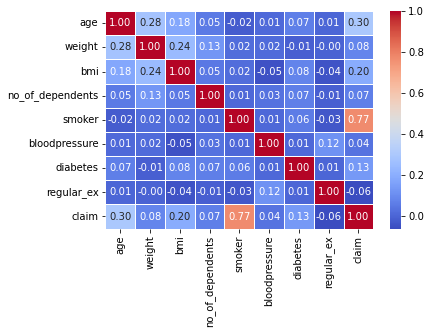

In [152]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [59]:
# There is a high correlation between smoking and insurance claim

<AxesSubplot:xlabel='claim'>

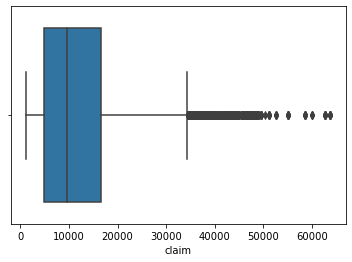

In [60]:
sns.boxplot(x=df['claim'])

In [61]:
#There seems to be a lot of lot of outlier in regard to the claim section

<AxesSubplot:xlabel='age', ylabel='claim'>

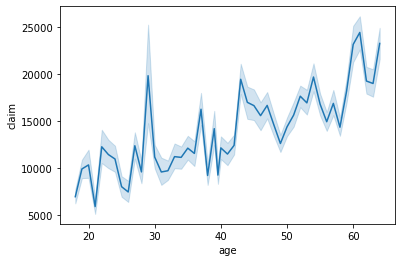

In [62]:
sns.lineplot(x=df['age'],y=df['claim'])

<AxesSubplot:xlabel='sex', ylabel='claim'>

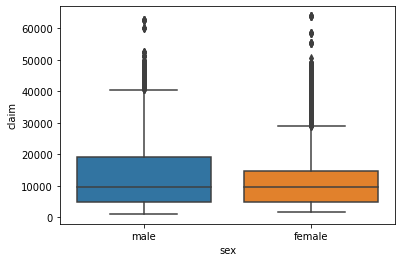

In [63]:
sns.boxplot(x=df['sex'],y=df['claim'])

In [64]:
outlier_female = df[(df['sex']=='female') &  (df['claim']>=30000)]
outlier_female

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
2,32.0,female,64,17.800000,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.400000,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
10,51.0,female,50,33.000000,EyeDisease,0,1,Syracuse,72,1,0,Police,44400.4
77,23.0,female,45,26.700000,NoDisease,0,1,Prescott,82,1,0,Academician,34166.3
111,26.0,female,75,30.273483,NoDisease,1,1,Oxnard,80,1,0,Clerks,34564.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14844,37.0,female,70,30.273483,Cancer,0,1,Kingman,78,1,0,Buisnessman,37270.2
14865,59.0,female,58,36.800000,NoDisease,1,1,Raleigh,56,1,0,HomeMakers,47896.8
14968,26.0,female,57,32.500000,Arthritis,0,1,Nashville,65,0,1,Manager,35908.7
14977,45.0,female,84,30.273483,NoDisease,1,1,Cambridge,72,1,1,ITProfessional,39725.5


In [65]:
outlier = df[df['claim']>=40000]

In [66]:
outlier

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
3,61.0,female,53,36.400000,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
10,51.0,female,50,33.000000,EyeDisease,0,1,Syracuse,72,1,0,Police,44400.4
27,38.0,male,82,38.400000,Alzheimer,3,1,Nashville,86,1,0,Dancer,41949.2
115,43.0,male,62,38.100000,NoDisease,2,1,Montrose,80,1,0,Dancer,42560.4
120,51.0,female,50,33.000000,EyeDisease,0,1,Tucson,72,1,0,Police,44400.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14869,57.0,male,73,42.100000,NoDisease,1,1,SanJose,60,1,0,Clerks,48675.5
14935,39.0,male,74,35.300000,NoDisease,2,1,SanJose,64,1,0,Architect,40103.9
14959,54.0,male,81,30.273483,NoDisease,1,1,Newport,76,1,0,Singer,41999.5
14983,37.0,female,76,38.400000,HeartDisease,0,1,Louisville,86,1,0,ITProfessional,40419.0


<AxesSubplot:xlabel='claim', ylabel='Count'>

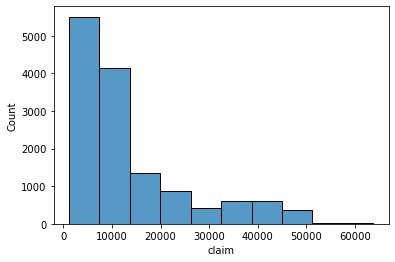

In [67]:
sns.histplot(df['claim'],bins = 10)

In [68]:
df['city'].unique()

array(['NewYork', 'Boston', 'Phildelphia', 'Pittsburg', 'Buffalo',
       'AtlanticCity', 'Portland', 'Cambridge', 'Hartford', 'Springfield',
       'Syracuse', 'Baltimore', 'York', 'Trenton', 'Warwick',
       'WashingtonDC', 'Providence', 'Harrisburg', 'Newport', 'Stamford',
       'Worcester', 'Atlanta', 'Brimingham', 'Charleston', 'Charlotte',
       'Louisville', 'Memphis', 'Nashville', 'NewOrleans', 'Raleigh',
       'Houston', 'Georgia', 'Oklahoma', 'Orlando', 'Macon', 'Huntsville',
       'Knoxville', 'Florence', 'Miami', 'Tampa', 'PanamaCity',
       'Kingsport', 'Marshall', 'Mandan', 'Waterloo', 'IowaCity',
       'Columbia', 'Indianapolis', 'Cincinnati', 'Bloomington', 'Salina',
       'KanasCity', 'Brookings', 'Minot', 'Chicago', 'Lincoln',
       'FallsCity', 'GrandForks', 'Fargo', 'Cleveland', 'Canton',
       'Columbus', 'Rochester', 'Minneapolis', 'JeffersonCity',
       'Escabana', 'Youngstown', 'SantaRosa', 'Eureka', 'SanFrancisco',
       'SanJose', 'LosAngeles', 'Ox

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

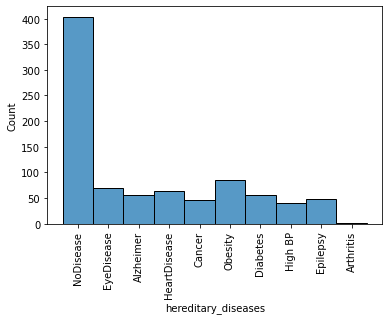

In [69]:
sns.histplot(outlier['hereditary_diseases'],bins = 20)
plt.xticks(rotation=90)

In [70]:
filtered_outlier = outlier[outlier['hereditary_diseases'].str.contains('NoDisease')]

In [71]:
filtered_outlier

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
3,61.0,female,53,36.400000,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
115,43.0,male,62,38.100000,NoDisease,2,1,Montrose,80,1,0,Dancer,42560.4
150,51.0,female,56,37.100000,NoDisease,3,1,Houston,92,1,0,Architect,46255.1
207,43.0,female,43,22.500000,NoDisease,3,1,Charlotte,70,1,0,DataScientist,40941.3
307,60.0,male,69,39.900000,NoDisease,0,1,Eureka,72,1,0,Blogger,48173.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14866,63.0,male,83,35.100000,NoDisease,0,1,Houston,85,1,0,FashionDesigner,47055.5
14869,57.0,male,73,42.100000,NoDisease,1,1,SanJose,60,1,0,Clerks,48675.5
14935,39.0,male,74,35.300000,NoDisease,2,1,SanJose,64,1,0,Architect,40103.9
14959,54.0,male,81,30.273483,NoDisease,1,1,Newport,76,1,0,Singer,41999.5


In [72]:
filtered_outlier[filtered_outlier['diabetes']==0]

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
1937,60.0,male,79,32.800000,NoDisease,0,1,Providence,75,0,0,Doctor,52590.8
3488,47.0,male,71,30.273483,NoDisease,3,0,Macon,63,0,0,Analyst,40114.8
4051,49.0,male,90,37.800000,NoDisease,2,1,Georgia,72,0,1,HouseKeeper,40748.2
4703,34.0,female,74,37.700000,NoDisease,1,1,WashingtonDC,81,0,0,Technician,50386.0
5512,60.0,male,79,32.800000,NoDisease,0,1,Waterloo,75,0,0,Doctor,52590.8
9875,60.0,male,79,32.800000,NoDisease,0,1,Brookings,75,0,0,Doctor,52590.8
10562,60.0,male,79,32.800000,NoDisease,0,1,Charleston,75,0,0,Doctor,52590.8
11001,60.0,male,79,32.800000,NoDisease,0,1,Miami,75,0,0,Doctor,52590.8
12067,23.0,female,55,45.700000,NoDisease,1,1,LasVegas,51,0,1,Student,40245.6
14053,53.0,female,85,33.300000,NoDisease,2,1,Louisville,72,0,0,FilmMaker,42718.4


In [73]:
df [ df['hereditary_diseases'].str.contains('Diabetes') ]

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
148,29.000000,male,77,32.200000,Diabetes,0,1,NewOrleans,83,1,1,Lawyer,35858.2
277,24.000000,male,56,24.700000,Diabetes,0,1,Miami,74,1,0,Student,34254.1
345,43.000000,female,79,46.200000,Diabetes,0,1,Houston,110,1,0,Dancer,45863.2
610,39.556598,male,80,34.400000,Diabetes,0,1,Montrose,90,1,0,Doctor,36197.7
704,24.000000,male,56,24.700000,Diabetes,0,1,Memphis,74,1,0,Student,34254.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14386,33.000000,male,65,30.273483,Diabetes,1,1,Oxnard,91,0,1,HomeMakers,24234.6
14422,35.000000,male,64,36.700000,Diabetes,1,1,Pittsburg,68,1,0,Architect,39774.3
14686,22.000000,male,59,37.600000,Diabetes,1,1,Trenton,78,1,0,Clerks,37165.2
14755,43.000000,female,79,46.200000,Diabetes,0,1,Buffalo,110,1,0,Dancer,45863.2


In [74]:
from sklearn.utils import resample


df_no_disease = df[df['hereditary_diseases'] == 'NoDisease']
df_diseases = df[df['hereditary_diseases'] != 'NoDisease']

# Oversample the minority classes (diseases)
df_diseases_oversampled = resample(df_diseases, 
                                   replace=True,      # With replacement (allow duplicates)
                                   n_samples=len(df_no_disease),  # Match the number of samples in 'No Disease'
                                   random_state=42)   # For reproducibility

# Combining the oversampled minority classes with the majority class
df_balanced = pd.concat([df_no_disease, df_diseases_oversampled])

print(df_balanced['hereditary_diseases'].value_counts())

NoDisease       12965
Diabetes         1900
Alzheimer        1870
Obesity          1749
EyeDisease       1566
Cancer           1532
Arthritis        1253
HeartDisease     1156
Epilepsy         1071
High BP           868
Name: hereditary_diseases, dtype: int64


In [75]:
bins = [17, 25, 40, 60, 100]  # Age ranges
labels = ['Young Adult', 'Adult', 'Middle-Aged', 'Senior']

# Create age categories
df_balanced['age_group'] = pd.cut(df_balanced['age'], bins=bins, labels=labels)

# bins = [0, 18.5, 24.9, 29.9, 40.0, 70.0]
# labels = ['Underweight', 'Normal weight', 'Overweight', 'Obese','Severe obese']

# # Create a new column for the BMI category
# df_balanced['bmi_category'] = pd.cut(df_balanced['bmi'], bins=bins, labels=labels, right=True)



In [76]:
df_balanced

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim,age_group
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6,Middle-Aged
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0,Middle-Aged
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6,Senior
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7,Young Adult
5,42.0,female,89,37.9,NoDisease,0,0,AtlanticCity,78,0,0,Dancer,6474.0,Middle-Aged
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1071,52.0,female,63,28.9,Alzheimer,0,1,NewYork,70,0,0,HomeMakers,30659.3,Middle-Aged
6184,44.0,female,57,39.0,Epilepsy,0,1,Pheonix,65,1,0,Manager,42983.5,Middle-Aged
14268,36.0,male,63,26.5,Arthritis,1,1,Charlotte,98,0,1,Dancer,22473.7,Adult
4130,34.0,male,67,34.3,Cancer,3,0,LosAngeles,76,1,1,Journalist,34575.1,Adult


In [77]:
age_group  = {
    'Young Adult':1, 'Adult':2, 'Middle-Aged':3, 'Senior':4
}

In [78]:
df_balanced['age_rank'] = df_balanced['age_group'].map(age_group)

In [79]:
# bmi_mapping = {
#     'Underweight': 0,
#     'Normal weight': 1,
#     'Overweight': 2,
#     'Obese': 3,
#     'Severe obese':4
# }

# # Apply the mapping
# df_balanced['bmi_rank'] = df_balanced['bmi_category'].map(bmi_mapping)



In [80]:
df_balanced

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim,age_group,age_rank
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6,Middle-Aged,3
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0,Middle-Aged,3
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6,Senior,4
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7,Young Adult,1
5,42.0,female,89,37.9,NoDisease,0,0,AtlanticCity,78,0,0,Dancer,6474.0,Middle-Aged,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1071,52.0,female,63,28.9,Alzheimer,0,1,NewYork,70,0,0,HomeMakers,30659.3,Middle-Aged,3
6184,44.0,female,57,39.0,Epilepsy,0,1,Pheonix,65,1,0,Manager,42983.5,Middle-Aged,3
14268,36.0,male,63,26.5,Arthritis,1,1,Charlotte,98,0,1,Dancer,22473.7,Adult,2
4130,34.0,male,67,34.3,Cancer,3,0,LosAngeles,76,1,1,Journalist,34575.1,Adult,2


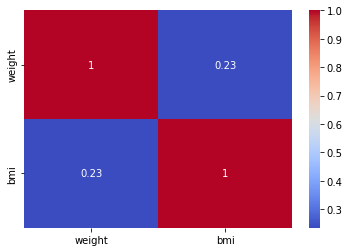

In [81]:
corr_matrix = df_balanced[['weight', 'bmi']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

In [82]:
#df_encoded = pd.get_dummies(df, columns=['a'], prefix='Disease')

In [83]:
#Affecting factors - age,hereditary_diseases,smoker,diabetes, regular_ex

In [84]:
numeric_col = df.select_dtypes(['int64','float64'])

In [85]:
numeric_col

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
0,60.0,64,24.3,1,0,72,0,0,13112.6
1,49.0,75,22.6,1,0,78,1,1,9567.0
2,32.0,64,17.8,2,1,88,1,1,32734.2
3,61.0,53,36.4,1,1,72,1,0,48517.6
4,19.0,50,20.6,0,0,82,1,0,1731.7
...,...,...,...,...,...,...,...,...,...
14994,38.0,71,27.3,1,0,72,1,0,6555.1
14995,39.0,49,28.3,1,1,54,1,0,21082.2
14996,39.0,74,29.6,4,0,64,1,0,7512.3
14998,52.0,88,36.7,0,0,70,1,0,9144.6


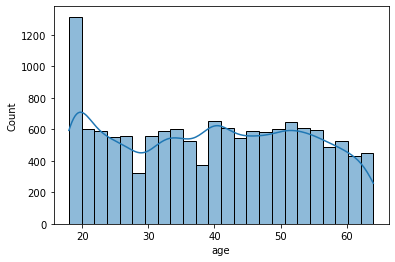

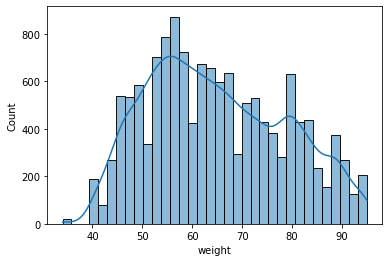

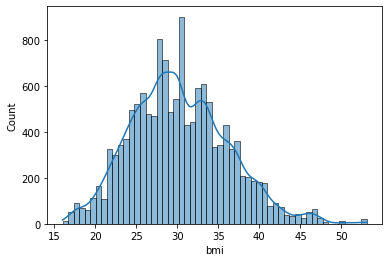

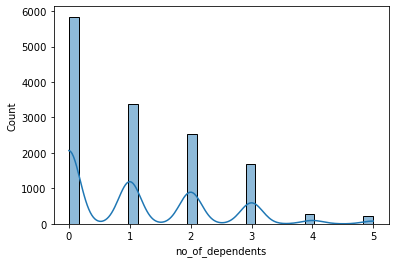

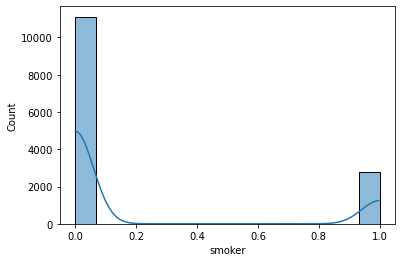

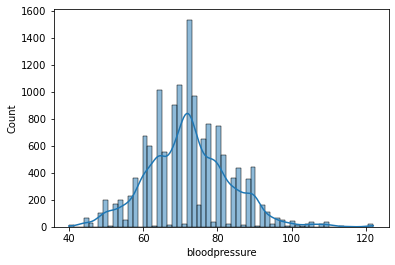

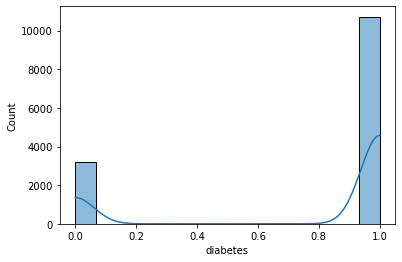

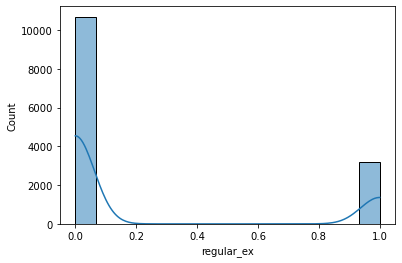

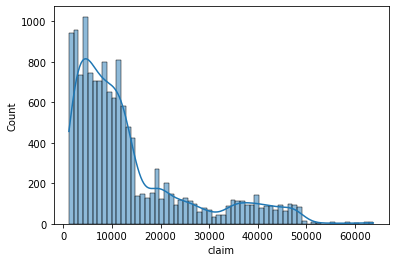

In [86]:
for col in numeric_col:
    sns.histplot(x =df[col],kde = True)
    plt.show()

In [87]:
df.columns

Index(['age', 'sex', 'weight', 'bmi', 'hereditary_diseases',
       'no_of_dependents', 'smoker', 'city', 'bloodpressure', 'diabetes',
       'regular_ex', 'job_title', 'claim'],
      dtype='object')

In [88]:
categorical_cols = ['sex','hereditary_diseases','no_of_dependents','smoker','diabetes','regular_ex','job_title']

In [89]:
for each_col in categorical_cols:
    print(each_col,df[each_col].unique())

sex ['male' 'female']
hereditary_diseases ['NoDisease' 'Epilepsy' 'EyeDisease' 'Alzheimer' 'Arthritis'
 'HeartDisease' 'Diabetes' 'Cancer' 'High BP' 'Obesity']
no_of_dependents [1 2 0 3 4 5]
smoker [0 1]
diabetes [0 1]
regular_ex [0 1]
job_title ['Actor' 'Engineer' 'Academician' 'Chef' 'HomeMakers' 'Dancer' 'Singer'
 'DataScientist' 'Police' 'Student' 'Doctor' 'Manager' 'Photographer'
 'Beautician' 'CA' 'Blogger' 'CEO' 'Labourer' 'Accountant' 'FilmDirector'
 'Technician' 'FashionDesigner' 'Architect' 'HouseKeeper' 'FilmMaker'
 'Buisnessman' 'Politician' 'DefencePersonnels' 'Analyst' 'Clerks'
 'ITProfessional' 'Farmer' 'Journalist' 'Lawyer' 'GovEmployee']


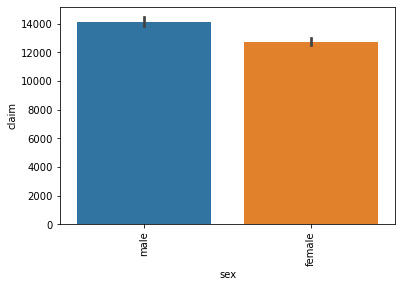

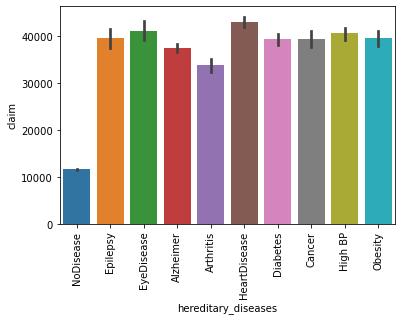

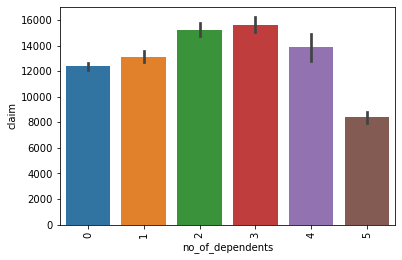

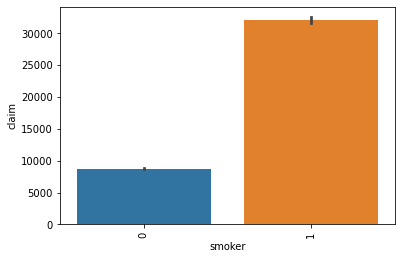

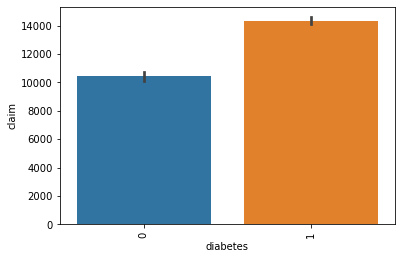

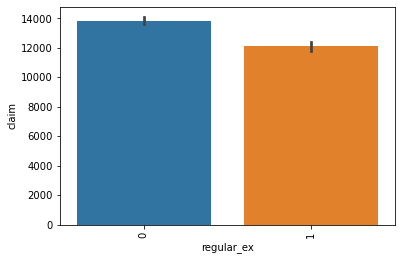

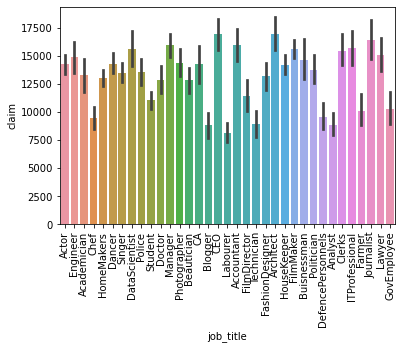

In [90]:
for each_col in categorical_cols:
    sns.barplot(x= df[each_col],y = df['claim'])
    plt.xticks(rotation = 90)
    plt.show()

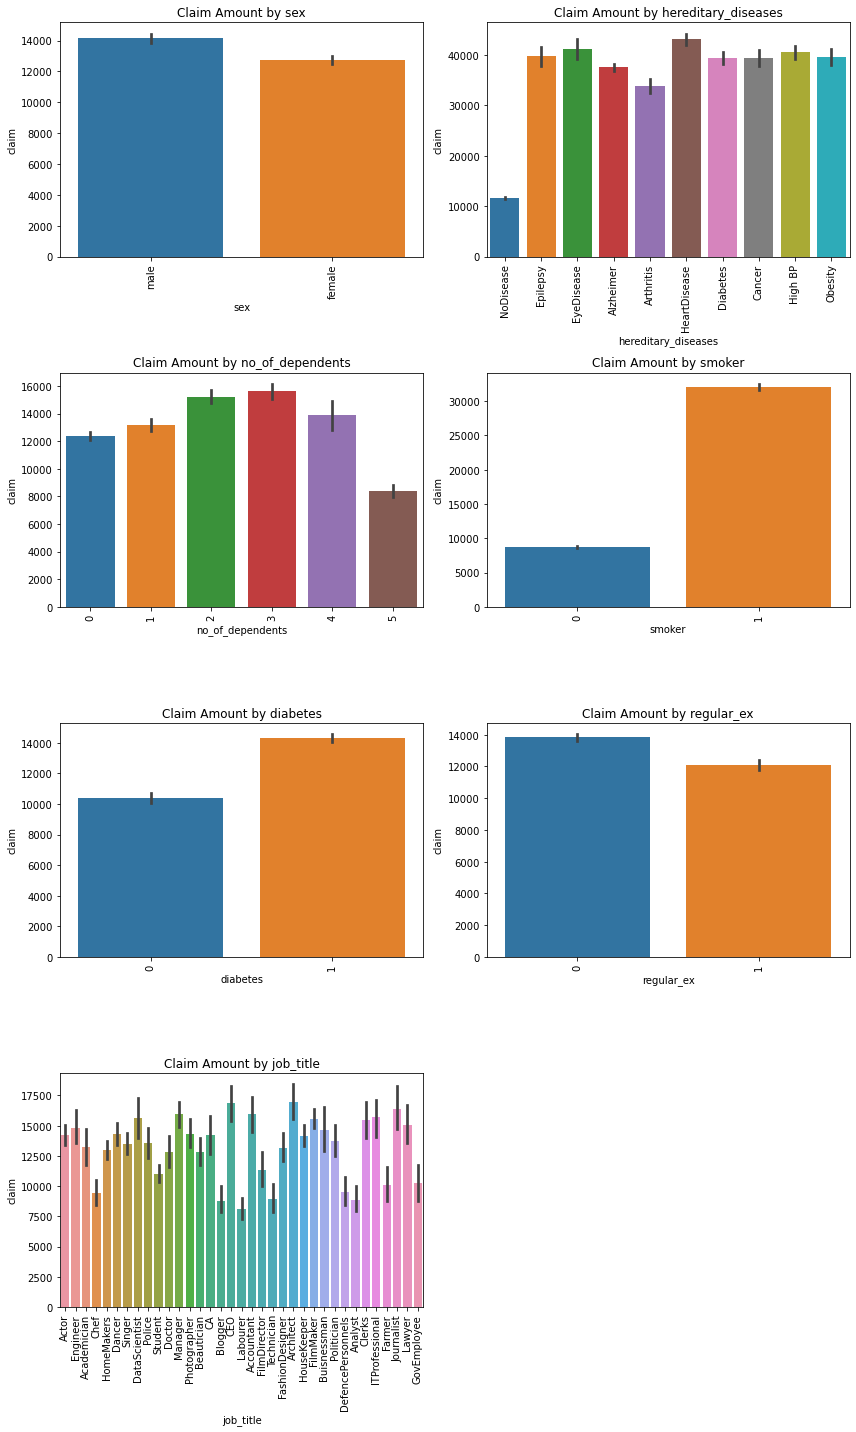

In [91]:
cols = 2  # Two charts per row
rows = (len(categorical_cols) + 1) // cols  # Calculate required rows

fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))  # Create subplots
axes = axes.flatten()  # Flatten axes array for easy iteration

# Loop through categorical columns and create barplots
for i, each_col in enumerate(categorical_cols):
    sns.barplot(x=df[each_col], y=df['claim'], ax=axes[i])
    axes[i].set_title(f'Claim Amount by {each_col}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)  # Rotate x-axis labels

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Delete extra empty subplots

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

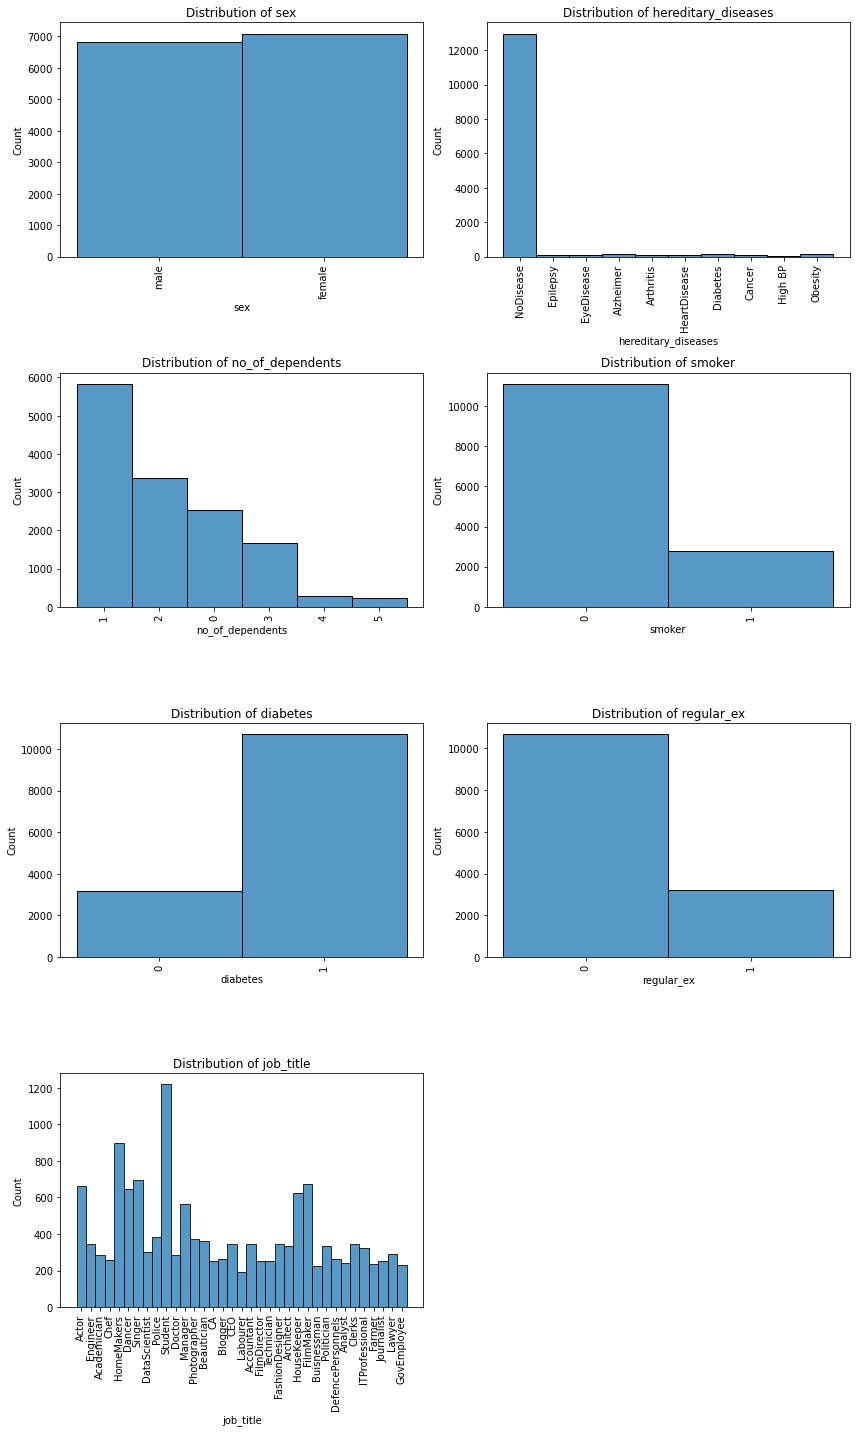

In [92]:
# Define number of columns per row
cols = 2  # Two charts per row
rows = (len(categorical_cols) + 1) // cols  # Calculate required rows

fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))  # Create subplots
axes = axes.flatten()  # Flatten axes array for easy iteration

# Loop through categorical columns and create histogram plots
for i, each_col in enumerate(categorical_cols):
    sns.histplot(df[each_col], ax=axes[i], discrete=True)  # `discrete=True` ensures categorical data is handled correctly
    axes[i].set_title(f'Distribution of {each_col}')
    
    # Explicitly set the tick labels based on unique values in the column
    unique_categories = df[each_col].unique()
    axes[i].set_xticks(range(len(unique_categories)))  # Set correct tick positions
    axes[i].set_xticklabels(unique_categories, rotation=90)  # Rotate labels properly
# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Delete extra empty subplots
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

# Feature Engineering

In [93]:
df_balanced['hereditary_diseases'].unique()

array(['NoDisease', 'Obesity', 'Alzheimer', 'Diabetes', 'Cancer',
       'HeartDisease', 'EyeDisease', 'Arthritis', 'High BP', 'Epilepsy'],
      dtype=object)

In [94]:
df_balanced.columns

Index(['age', 'sex', 'weight', 'bmi', 'hereditary_diseases',
       'no_of_dependents', 'smoker', 'city', 'bloodpressure', 'diabetes',
       'regular_ex', 'job_title', 'claim', 'age_group', 'age_rank'],
      dtype='object')

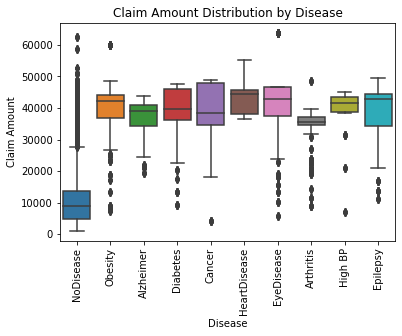

In [95]:
sns.boxplot(x=df_balanced['hereditary_diseases'], y=df_balanced['claim'])

plt.xticks(rotation=90)

plt.title("Claim Amount Distribution by Disease")
plt.xlabel("Disease")
plt.ylabel("Claim Amount")

plt.show()


we are going to rank the diseases in order of high risk and claim amount

Alzheimer, Heart Disease, Cancer → Have the highest median claims and large spread, meaning high severity.
Epilepsy & Diabetes → Have moderate-to-high claim values but less variability than high-risk diseases.
NoDisease → Expectedly has the lowest claim values, meaning low risk.

In [96]:
df_encoded = pd.get_dummies(df_balanced, columns=['hereditary_diseases'], prefix='Disease')

In [97]:
df_encoded.head()

,age,sex,weight,bmi,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,...,Disease_Alzheimer,Disease_Arthritis,Disease_Cancer,Disease_Diabetes,Disease_Epilepsy,Disease_EyeDisease,Disease_HeartDisease,Disease_High BP,Disease_NoDisease,Disease_Obesity
0,60.0,male,64,24.3,1,0,NewYork,72,0,0,...,0,0,0,0,0,0,0,0,1,0
1,49.0,female,75,22.6,1,0,Boston,78,1,1,...,0,0,0,0,0,0,0,0,1,0
3,61.0,female,53,36.4,1,1,Pittsburg,72,1,0,...,0,0,0,0,0,0,0,0,1,0
4,19.0,female,50,20.6,0,0,Buffalo,82,1,0,...,0,0,0,0,0,0,0,0,1,0
5,42.0,female,89,37.9,0,0,AtlanticCity,78,0,0,...,0,0,0,0,0,0,0,0,1,0


In [98]:
df_encoded.columns

Index(['age', 'sex', 'weight', 'bmi', 'no_of_dependents', 'smoker', 'city',
       'bloodpressure', 'diabetes', 'regular_ex', 'job_title', 'claim',
       'age_group', 'age_rank', 'Disease_Alzheimer', 'Disease_Arthritis',
       'Disease_Cancer', 'Disease_Diabetes', 'Disease_Epilepsy',
       'Disease_EyeDisease', 'Disease_HeartDisease', 'Disease_High BP',
       'Disease_NoDisease', 'Disease_Obesity'],
      dtype='object')

In [99]:
df_encoded.sample(20)

,age,sex,weight,bmi,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,...,Disease_Alzheimer,Disease_Arthritis,Disease_Cancer,Disease_Diabetes,Disease_Epilepsy,Disease_EyeDisease,Disease_HeartDisease,Disease_High BP,Disease_NoDisease,Disease_Obesity
5305,18.0,male,51,26.400000,0,1,Houston,92,1,0,...,0,1,0,0,0,0,0,0,0,0
5410,49.0,female,57,37.400000,4,0,Stamford,72,1,0,...,0,0,0,0,0,0,0,0,1,0
3921,47.0,female,82,26.600000,2,0,Kingsport,70,1,0,...,0,0,0,0,0,0,0,0,1,0
4662,59.0,female,62,27.500000,0,0,Huntsville,68,1,0,...,0,0,0,0,0,0,0,0,1,0
725,51.0,male,59,31.600000,0,0,Kingman,72,1,0,...,0,0,0,0,0,0,0,0,1,0
3309,19.0,male,59,31.300000,0,1,AtlanticCity,69,0,1,...,0,0,0,0,0,0,0,0,1,0
4136,56.0,female,80,28.800000,0,0,Prescott,80,1,0,...,0,0,0,0,0,0,0,0,1,0
8885,32.0,male,56,35.200000,2,0,Nashville,64,1,1,...,0,0,0,0,0,0,0,0,1,0
10343,34.0,female,81,30.273483,1,1,Canton,66,1,0,...,0,0,0,0,1,0,0,0,0,0
2706,32.0,male,56,30.273483,3,0,Boston,72,1,0,...,0,0,0,0,0,0,0,0,1,0


In [100]:
df_encoded['sex']= df_encoded['sex'].map({'male':0,'female':1})

In [101]:
columns_to_scale = ['bloodpressure', 'bmi']


In [102]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_encoded[columns_to_scale] = scaler.fit_transform(df_encoded[columns_to_scale])

In [103]:
df_encoded.columns

Index(['age', 'sex', 'weight', 'bmi', 'no_of_dependents', 'smoker', 'city',
       'bloodpressure', 'diabetes', 'regular_ex', 'job_title', 'claim',
       'age_group', 'age_rank', 'Disease_Alzheimer', 'Disease_Arthritis',
       'Disease_Cancer', 'Disease_Diabetes', 'Disease_Epilepsy',
       'Disease_EyeDisease', 'Disease_HeartDisease', 'Disease_High BP',
       'Disease_NoDisease', 'Disease_Obesity'],
      dtype='object')

In [104]:
df2 = df_encoded.drop(columns = ['age','weight','city','job_title','age'])

In [105]:
df2.columns

Index(['sex', 'bmi', 'no_of_dependents', 'smoker', 'bloodpressure', 'diabetes',
       'regular_ex', 'claim', 'age_group', 'age_rank', 'Disease_Alzheimer',
       'Disease_Arthritis', 'Disease_Cancer', 'Disease_Diabetes',
       'Disease_Epilepsy', 'Disease_EyeDisease', 'Disease_HeartDisease',
       'Disease_High BP', 'Disease_NoDisease', 'Disease_Obesity'],
      dtype='object')

In [106]:
# df2['bmi_rank'] = df2['bmi_rank'].astype('category')
# df2['age_rank'] = df2['age_rank'].astype('category')

In [107]:
X=df2[['sex', 'no_of_dependents', 'smoker', 'bloodpressure', 'diabetes',
       'regular_ex', 'age_rank',
       'bmi', 'Disease_Alzheimer', 'Disease_Arthritis', 'Disease_Cancer',
       'Disease_Diabetes', 'Disease_Epilepsy', 'Disease_EyeDisease',
       'Disease_HeartDisease', 'Disease_High BP', 'Disease_NoDisease',
       'Disease_Obesity']]
y=df2['claim']

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)
print(train_score,test_score)
# Print coefficients
print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

0.8785823006924753 0.8826108863015822
Model Coefficients: [   -80.41946349    470.81709204  17699.12594008   2476.49354628
   2707.88853042  -2043.5980438    3527.96774083   9786.65518907
   1101.38796288  -1081.81319718   2027.14837494   -294.20141345
   1562.83300489   1699.78617094   4700.1969417     649.55364113
 -11391.47260172   1026.58111587]
Intercept: 5409.29904541621


In [110]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
mse_lr = mean_squared_error(y_test,y_pred)
rmse_lr = np.sqrt(mse_lr)
print('Linera Regression ==> MSE:', mse_lr,'RMSE:',rmse_lr)

Linera Regression ==> MSE: 32349450.13316175 RMSE: 5687.657701827858


In [111]:
y_pred = model.predict(X_test)
residualss = y_pred-y_test
residualss_pct = (residualss*100)/y_test

resultss_df = pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residualss,
    'diff_pct':residualss_pct
})
resultss_df.tail()

,actual,predicted,diff,diff_pct
11243,41661.6,43071.512544,1409.912544,3.384202
7169,10269.5,14169.510117,3900.010117,37.976631
3668,10942.1,11229.424413,287.324413,2.625862
12014,7441.5,8905.539261,1464.039261,19.673981
1269,38792.7,35503.092781,-3289.607219,-8.479965


In [112]:
extreme_res = resultss_df[np.abs(resultss_df.diff_pct)>50].sort_values('diff_pct',ascending = False)
extreme_res

,actual,predicted,diff,diff_pct
7498,1163.5,7402.931186,6239.431186,536.263961
4472,1163.5,7402.931186,6239.431186,536.263961
8701,7004.8,41186.134002,34181.334002,487.970163
8701,7004.8,41186.134002,34181.334002,487.970163
8768,1137.0,6538.361290,5401.361290,475.053763
...,...,...,...,...
8012,1628.5,-1790.345136,-3418.845136,-209.938295
8775,1628.5,-1790.345136,-3418.845136,-209.938295
7298,1607.5,-2224.784278,-3832.284278,-238.400266
5442,1702.5,-2382.526914,-4085.026914,-239.942844


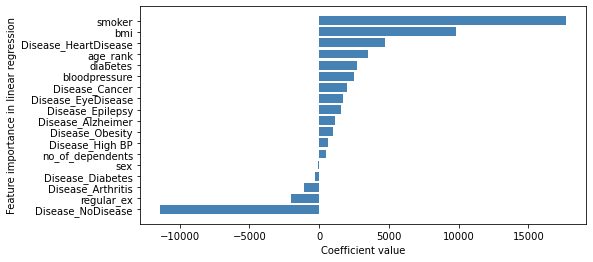

In [113]:
feature_importances = model.coef_
coef_df = pd.DataFrame(feature_importances,index = X_test.columns,columns = ['coefficients'])
coef_df = coef_df.sort_values(by='coefficients',ascending=True)
plt.figure(figsize = (8,4))
plt.barh(coef_df.index,coef_df['coefficients'],color = 'steelblue')
plt.xlabel('Coefficient value')
plt.ylabel('Feature importance in linear regression')
plt.show()

In [114]:
from sklearn.linear_model import Ridge
model_rg = Ridge()
model_rg.fit(X_train, y_train)
train_score = model_rg.score(X_train,y_train)
test_score = model_rg.score(X_test,y_test)
print(train_score,test_score)
# Print coefficients
print("Model Coefficients:", model_rg.coef_)
print("Intercept:", model_rg.intercept_)

0.8785822433168217 0.8826122590867751
Model Coefficients: [   -80.74030525    470.85980384  17693.84559738   2467.09582766
   2708.34740066  -2044.07090794   3528.30944205   9767.1808905
   1100.6258171   -1079.67378771   2027.19167625   -290.69114468
   1561.60029726   1701.55774655   4696.77500961    650.18776509
 -11394.47500926   1026.90162953]
Intercept: 5424.492626748412


In [115]:
from xgboost import XGBRegressor

# model_xgb = XGBRegressor()

# model_xgb.fit(X_train, y_train)
# train_score = model_xgb.score(X_train,y_train)
# test_score = model_xgb.score(X_test,y_test)
# print(train_score,test_score)
# # Print coefficients

In [116]:
# from sklearn.metrics import mean_squared_error, r2_score
# y_pred = model_xgb.predict(X_test)
# mse_xgb = mean_squared_error(y_test,y_pred)
# rmse_xgb = np.sqrt(mse_xgb)
# print('XGBoost Regression ==> MSE:', mse_xgb,'RMSE:',rmse_xgb)

In [117]:
# y_pred = model_xgb.predict(X_test)
# residuals = y_pred-y_test
# residuals_pct = residuals*100/y_test

# results_df = pd.DataFrame({
#     'actual':y_test,
#     'predicted':y_pred,
#     'diff':residuals,
#     'diff_pct':residuals_pct
# })
# results_df.head()

In [118]:
# sns.histplot(results_df['diff_pct'],kde=True)

In [119]:
# extreme_results = results_df[np.abs(results_df.diff_pct)>50].sort_values('diff_pct',ascending = False)

In [120]:
# extreme_results

In [121]:
# extreme_results_df = X_test.loc[extreme_results.index]
# extreme_results_df

In [122]:
# from xgboost import plot_importance

# plot_importance(model_xgb)
# plt.show()

In [123]:
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

In [124]:
rf_regressor.fit(X_train, y_train)

trains_score = rf_regressor.score(X_train,y_train)
tests_score = rf_regressor.score(X_test,y_test)
print(trains_score,tests_score)
# Predict on the test data
y_pred = rf_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
rmse = np.sqrt(mse)
print('Random Regression ==> MSE:', mse,'RMSE:',rmse)

0.9987010186300499 0.9930700859931815
Mean Squared Error: 1909707.8129971006
Random Regression ==> MSE: 1909707.8129971006 RMSE: 1381.9217825177736


In [125]:
y_pred = rf_regressor.predict(X_test)
residualss = y_pred-y_test
residualss_pct = (residualss*100)/y_test

resultss_df = pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residualss,
    'diff_pct':residualss_pct
})
resultss_df.tail()

,actual,predicted,diff,diff_pct
11243,41661.6,41661.600,1.455192e-11,3.492884e-14
7169,10269.5,10269.500,0.000000e+00,0.000000e+00
3668,10942.1,10942.100,-1.273293e-11,-1.163664e-13
12014,7441.5,8606.881,1.165381e+03,1.566057e+01
1269,38792.7,38792.700,8.731149e-11,2.250720e-13


In [126]:
extreme_res = resultss_df[np.abs(resultss_df.diff_pct)>50].sort_values('diff_pct',ascending = False)

In [127]:
extreme_res

,actual,predicted,diff,diff_pct
9895,10081.1,40867.797,30786.697,305.390255
3789,6778.0,25352.984,18574.984,274.048156
2174,4463.1,15409.606,10946.506,245.266877
14462,7085.5,23171.820,16086.320,227.031543
14626,5216.7,15465.920,10249.220,196.469416
...,...,...,...,...
2269,17093.5,4853.386,-12240.114,-71.606833
13019,12286.1,3430.525,-8855.575,-72.077999
6069,14360.7,3578.734,-10781.966,-75.079669
3345,11150.3,2116.622,-9033.678,-81.017354


In [128]:
df_filtered= df_balanced[df_balanced['claim'].isin(extreme_res['actual'])]

In [129]:
df_filtered

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim,age_group,age_rank
234,49.0,male,59,26.100000,NoDisease,0,1,Pheonix,73,0,0,Actor,13571.0,Middle-Aged,3
346,26.0,female,79,22.200000,NoDisease,0,0,Georgia,102,0,1,Buisnessman,3176.3,Adult,2
393,26.0,male,59,29.200000,NoDisease,1,0,Miami,84,0,1,Beautician,2902.9,Adult,2
477,33.0,male,67,28.800000,NoDisease,4,1,Minot,81,0,0,HouseKeeper,6642.6,Adult,2
677,54.0,male,63,28.100000,NoDisease,0,0,Charleston,73,1,1,Police,24283.5,Middle-Aged,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14462,40.0,male,47,30.273483,NoDisease,0,1,Lincoln,72,0,0,FilmMaker,7085.5,Adult,2
14626,33.0,female,69,35.200000,NoDisease,0,1,Phildelphia,87,0,1,FashionDesigner,5216.7,Adult,2
14820,43.0,female,67,30.273483,NoDisease,0,1,IowaCity,76,0,1,Beautician,11721.9,Middle-Aged,3
14840,34.0,female,75,25.400000,NoDisease,1,1,LasVegas,90,1,1,Beautician,13603.8,Adult,2


In [130]:
df_encoded.columns

Index(['age', 'sex', 'weight', 'bmi', 'no_of_dependents', 'smoker', 'city',
       'bloodpressure', 'diabetes', 'regular_ex', 'job_title', 'claim',
       'age_group', 'age_rank', 'Disease_Alzheimer', 'Disease_Arthritis',
       'Disease_Cancer', 'Disease_Diabetes', 'Disease_Epilepsy',
       'Disease_EyeDisease', 'Disease_HeartDisease', 'Disease_High BP',
       'Disease_NoDisease', 'Disease_Obesity'],
      dtype='object')

In [131]:
df_filtered['smoker'].value_counts()

0    50
1    44
Name: smoker, dtype: int64

In [132]:
import shap
explainer = shap.TreeExplainer(rf_regressor)

# Compute SHAP values for test data
shap_values = explainer.shap_values(X_test)

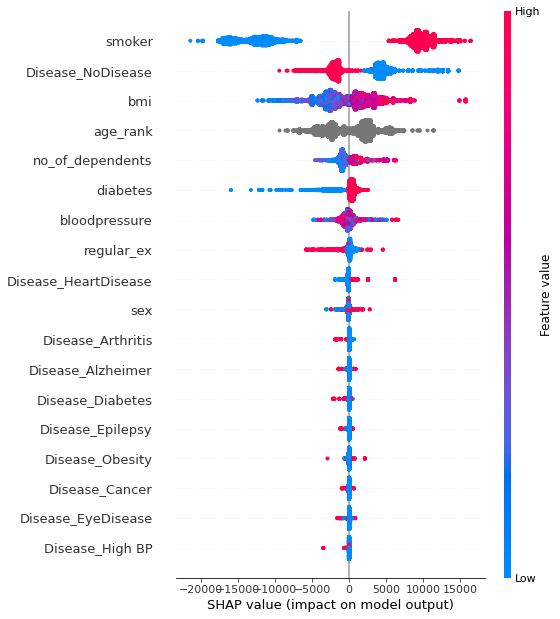

In [133]:
shap.summary_plot(shap_values, X_test)

In [134]:
from lightgbm import LGBMRegressor
model_lgb = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_lgb.fit(X_train, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 324
[LightGBM] [Info] Number of data points in the train set: 18151, number of used features: 18
[LightGBM] [Info] Start training from score 25485.362762


LGBMRegressor(random_state=42)

In [135]:
train_score_1 = model_lgb.score(X_train,y_train)
test_score_1 = model_lgb.score(X_test,y_test)
print(train_score_1,test_score_1)
# Print coefficients


0.9778084766834786 0.9752238223570542


In [136]:
# Evaluate the model
y_pred = model_lgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
rmse = np.sqrt(mse)
print('Gight GM ==> MSE:', mse,'RMSE:',rmse)

Mean Squared Error: 6827683.572174667
Gight GM ==> MSE: 6827683.572174667 RMSE: 2612.983653254392


In [137]:
y_pred = model_lgb.predict(X_test)
residualss = y_pred-y_test
residualss_pct = (residualss*100)/y_test

resultss_df = pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residualss,
    'diff_pct':residualss_pct
})
resultss_df.tail()

,actual,predicted,diff,diff_pct
11243,41661.6,41944.188779,282.588779,0.678296
7169,10269.5,11349.930851,1080.430851,10.520774
3668,10942.1,10326.062357,-616.037643,-5.629976
12014,7441.5,13904.801629,6463.301629,86.854823
1269,38792.7,38260.027919,-532.672081,-1.373125


In [138]:
extreme_res = resultss_df[np.abs(resultss_df.diff_pct)>50].sort_values('diff_pct',ascending = False)
extreme_res

,actual,predicted,diff,diff_pct
428,1252.4,9394.297982,8141.897982,650.103640
3881,1252.4,9394.297982,8141.897982,650.103640
3789,6778.0,34038.264087,27260.264087,402.187431
14626,5216.7,25157.597932,19940.897932,382.251192
9895,10081.1,39812.318665,29731.218665,294.920382
...,...,...,...,...
14376,34901.2,8014.426926,-26886.773074,-77.036816
8391,31080.6,6599.081100,-24481.518900,-78.767845
6903,20772.9,4285.983967,-16486.916033,-79.367426
12591,26964.7,4887.029216,-22077.670784,-81.876197


In [139]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)
train_score = model_dt.score(X_train,y_train)
test_score = model_dt.score(X_test,y_test)
print(train_score,test_score)


0.9121832236192062 0.9138480500546692


In [140]:
# Evaluate the model
y_pred = model_dt.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
rmse = np.sqrt(mse)
print('decision tree==> MSE:', mse,'RMSE:',rmse)

Mean Squared Error: 23741283.33391353
decision tree==> MSE: 23741283.33391353 RMSE: 4872.502779261756


In [141]:
y_pred = model_dt.predict(X_test)
residualss = y_pred-y_test
residualss_pct = (residualss*100)/y_test

resultss_df = pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residualss,
    'diff_pct':residualss_pct
})
resultss_df.tail()

,actual,predicted,diff,diff_pct
11243,41661.6,44133.406959,2471.806959,5.933058
7169,10269.5,11372.908552,1103.408552,10.744521
3668,10942.1,11372.908552,430.808552,3.937165
12014,7441.5,11372.908552,3931.408552,52.830861
1269,38792.7,38557.017772,-235.682228,-0.607543


In [142]:
extreme_res = resultss_df[np.abs(resultss_df.diff_pct)>50].sort_values('diff_pct',ascending = False)
extreme_res

,actual,predicted,diff,diff_pct
2978,4356.8,31298.743810,26941.943810,618.388354
8701,7004.8,44133.406959,37128.606959,530.045211
8701,7004.8,44133.406959,37128.606959,530.045211
14626,5216.7,31298.743810,26082.043810,499.972086
1323,8994.0,44133.406959,35139.406959,390.698321
...,...,...,...,...
9509,23083.0,3694.770347,-19388.229653,-83.993544
8204,25081.8,3694.770347,-21387.029653,-85.269118
3638,25081.8,3694.770347,-21387.029653,-85.269118
7913,27724.3,3694.770347,-24029.529653,-86.673170


In [154]:
import pandas as pd

# Example: Assume these lists contain the values for each model
models = ['Linear Regression', 'Random Forest', 'LightGBM','Decision Tree Regressor']
r2_scores = [0.88, 0.98, 0.97, 0.91]
mse_scores = [5687.65, 1381.92, 2612.98, 4872.50]
rmse_scores = [32349450.13, 1909707.81, 6827683.57,  23741283.33]
error_50_percent = [1594, 75, 662, 1315]  # Number of errors > 50%

# Create a DataFrame
df_results = pd.DataFrame({
    'Model': models,
    'R² Score': r2_scores,
    'MSE': mse_scores,
    'RMSE': rmse_scores,
    'Errors > 50%': error_50_percent,
    'Percentage of Errors': [(err / len(y_test)) * 100 for err in error_50_percent]  # Fixed calculation
})

# Display the table
print(df_results)


                     Model  R² Score      MSE         RMSE  Errors > 50%  \
0        Linear Regression      0.88  5687.65  32349450.13          1594   
1            Random Forest      0.98  1381.92   1909707.81            75   
2                 LightGBM      0.97  2612.98   6827683.57           662   
3  Decision Tree Regressor      0.91  4872.50  23741283.33          1315   

   Percentage of Errors  
0             20.491066  
1              0.964134  
2              8.510091  
3             16.904486  


In [155]:
df_results

,Model,R² Score,MSE,RMSE,Errors > 50%,Percentage of Errors
0,Linear Regression,0.88,5687.65,32349450.13,1594,20.491066
1,Random Forest,0.98,1381.92,1909707.81,75,0.964134
2,LightGBM,0.97,2612.98,6827683.57,662,8.510091
3,Decision Tree Regressor,0.91,4872.50,23741283.33,1315,16.904486


In [144]:
# Linera Regression ==> MSE: 32907076.202202704 RMSE: 5736.468966376678
#         Random Regression ==> MSE: 2840823.4840780357 RMSE: 1685.4742608767526
# MSE: 9791589.16213011 RMSE: 3129.1515083373815
#         MSE: 23663504.94032164 RMSE: 4864.51

In [145]:
best_model = rf_regressor

In [146]:
from joblib import dump
dump(best_model,"artifacts\\best_model.joblib")

['artifacts\\best_model.joblib']

In [147]:

scaler_with_cols = {
    'scaler':scaler,
    'columns_to_scale': columns_to_scale}
scaler_with_cols
dump(scaler_with_cols,"artifacts\\scaler.joblib")

['artifacts\\scaler.joblib']

In [148]:
import sklearn
print(sklearn.__version__)

1.6.1


In [149]:
pip install --upgrade scikit-learn

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\rgkam\anaconda3\lib\site-packages\pip\_internal\cli\base_command.py", line 106, in _run_wrapper
    status = _inner_run()
  File "C:\Users\rgkam\anaconda3\lib\site-packages\pip\_internal\cli\base_command.py", line 97, in _inner_run
    return self.run(options, args)
  File "C:\Users\rgkam\anaconda3\lib\site-packages\pip\_internal\cli\req_command.py", line 67, in wrapper
    return func(self, options, args)


  File "C:\Users\rgkam\anaconda3\lib\site-packages\pip\_internal\commands\install.py", line 484, in run
    installed_versions[distribution.canonical_name] = distribution.version
  File "C:\Users\rgkam\anaconda3\lib\site-packages\pip\_internal\metadata\pkg_resources.py", line 192, in version
    return parse_version(self._dist.version)
  File "C:\Users\rgkam\anaconda3\lib\site-packages\pip\_vendor\packaging\version.py", line 56, in parse
    return Version(version)
  File "C:\Users\rgkam\anaconda3\lib\site-packages\pip\_vendor\packaging\version.py", line 202, in __init__
    raise InvalidVersion(f"Invalid version: {version!r}")
pip._vendor.packaging.version.InvalidVersion: Invalid version: '4.0.0-unsupported'


In [150]:
scaler_with_cols

{'scaler': MinMaxScaler(), 'columns_to_scale': ['bloodpressure', 'bmi']}

In [151]:
X_test.columns

Index(['sex', 'no_of_dependents', 'smoker', 'bloodpressure', 'diabetes',
       'regular_ex', 'age_rank', 'bmi', 'Disease_Alzheimer',
       'Disease_Arthritis', 'Disease_Cancer', 'Disease_Diabetes',
       'Disease_Epilepsy', 'Disease_EyeDisease', 'Disease_HeartDisease',
       'Disease_High BP', 'Disease_NoDisease', 'Disease_Obesity'],
      dtype='object')

In [157]:
import joblib
print(joblib.__version__)

1.4.2


In [159]:
print(pd.__version__)

1.3.4


In [162]:
print(np.__version__)

1.20.3


In [164]:
print(rf_regressor.)

AttributeError: 'RandomForestRegressor' object has no attribute '__version__'